In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/pratikhiremath/uk-mortgage-rt/UK Mortgage Interest Rates.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from IPython.display import display, Markdown

sns.set_style("darkgrid")
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)

RATE_COLS = [
    'Fixed_Rate_2y_95%_LTV',
    'Fixed_Rate_2y_75%_LTV',
    'Fixed_Rate_3y_75%_LTV',
    'Tracker',
    'Variable Rate'
]
pct_fmt = FuncFormatter(lambda y, _: f'{y:.1%}')

Load and parse

In [3]:
df = pd.read_csv('/kaggle/input/datasets/pratikhiremath/uk-mortgage-rt/UK Mortgage Interest Rates.csv')
# Document decision 1: date parsing
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df = df.sort_values('Date').set_index('Date')

print(f"Date range: {df.index.min().date()} → {df.index.max().date()}")
print(f"Shape: {df.shape}")
df.tail()

Date range: 1999-01-01 → 2023-10-01
Shape: (298, 8)


,Fixed_Rate_2y_95%_LTV,Fixed_Rate_2y_75%_LTV,Fixed_Rate_3y_75%_LTV,Tracker,Variable Rate,Bank_Rate,LIBOR_3m,Gov_Bond_Yield_10y
Date,,,,,,,,
2023-06-01,0.0628,0.0549,0.0516,NaN,0.0747,0.0500,NaN,0.0444
2023-07-01,0.0688,0.0625,0.0594,NaN,0.0760,0.0500,NaN,0.0429
2023-08-01,0.0692,0.0621,0.0602,NaN,0.0785,0.0525,NaN,0.0439
2023-09-01,0.0675,0.0594,0.0578,NaN,0.0793,0.0525,NaN,0.0445
2023-10-01,0.0660,0.0563,0.0544,NaN,0.0801,0.0525,NaN,0.0453


Data quality audit

In [4]:
cleaning_log = []

# Check 1: missing values
nulls = df[RATE_COLS].isnull().sum()
null_pct = (nulls / len(df) * 100).round(2)
print("=== NULL AUDIT ===")
print(pd.DataFrame({'count': nulls, 'pct': null_pct}))
cleaning_log.append(f"Null check: {nulls.sum()} total nulls across rate columns")

# Check 2: negative or zero rates (data error indicator)
for col in RATE_COLS:
    bad = df[col][df[col] <= 0].count()
    if bad > 0:
        print(f"{col}: {bad} zero/negative values")
        cleaning_log.append(f"Zero/negative rates found in {col}: {bad} rows")

# Check 3: implausible spikes (>5% single-period change)
for col in RATE_COLS:
    delta = df[col].diff().abs()
    spikes = delta[delta > 0.05]
    if len(spikes) > 0:
        print(f"\n{col} spikes >5% in one period:")
        print(spikes)
        cleaning_log.append(f"{col}: {len(spikes)} spike(s) detected, reviewed manually")

# Check 4: date gaps (missing months)
date_gaps = pd.date_range(df.index.min(), df.index.max(), freq='MS')
missing_months = date_gaps.difference(df.index)
print(f"\nMissing months: {len(missing_months)}")
cleaning_log.append(f"Date continuity: {len(missing_months)} missing months")

=== NULL AUDIT ===
                       count     pct
Fixed_Rate_2y_95%_LTV     65 21.8100
Fixed_Rate_2y_75%_LTV      0  0.0000
Fixed_Rate_3y_75%_LTV      0  0.0000
Tracker                   51 17.1100
Variable Rate              0  0.0000
Tracker: 1 zero/negative values

Missing months: 0


Write the cleaning log


In [5]:
with open('cleaning_log.md', 'w') as f:
    f.write("# Data Cleaning Log — UK Mortgage Rate Analysis\n\n")
    f.write(f"**Dataset**: UK Mortgage Interest Rates (Kaggle)\n")
    f.write(f"**Date range**: {df.index.min().date()} to {df.index.max().date()}\n")
    f.write(f"**Rows**: {len(df)} | **Columns**: {len(df.columns)}\n\n")
    f.write("## Decisions Made\n\n")
    for i, entry in enumerate(cleaning_log, 1):
        f.write(f"{i}. {entry}\n")
    f.write("\n## Column Definitions\n\n")
    f.write("| Column | Description |\n|---|---|\n")
    f.write("| Fixed_Rate_2y_95%_LTV | 2-year fixed, 95% loan-to-value (first-time buyers) |\n")
    f.write("| Fixed_Rate_2y_75%_LTV | 2-year fixed, 75% LTV (lower risk borrowers) |\n")
    f.write("| Fixed_Rate_3y_75%_LTV | 3-year fixed, 75% LTV |\n")
    f.write("| Tracker | Tracks BoE base rate + margin |\n")
    f.write("| Variable Rate | Lender's standard variable rate |\n")

print("cleaning_log.md saved ")
display(Markdown(open('cleaning_log.md').read()))

cleaning_log.md saved 


# Data Cleaning Log — UK Mortgage Rate Analysis

**Dataset**: UK Mortgage Interest Rates (Kaggle)
**Date range**: 1999-01-01 to 2023-10-01
**Rows**: 298 | **Columns**: 8

## Decisions Made

1. Null check: 116 total nulls across rate columns
2. Zero/negative rates found in Tracker: 1 rows
3. Date continuity: 0 missing months

## Column Definitions

| Column | Description |
|---|---|
| Fixed_Rate_2y_95%_LTV | 2-year fixed, 95% loan-to-value (first-time buyers) |
| Fixed_Rate_2y_75%_LTV | 2-year fixed, 75% LTV (lower risk borrowers) |
| Fixed_Rate_3y_75%_LTV | 3-year fixed, 75% LTV |
| Tracker | Tracks BoE base rate + margin |
| Variable Rate | Lender's standard variable rate |


Clear Summary Stats


In [6]:
summary = df[RATE_COLS].describe().T
summary.columns = ['count','mean','std','min','25%','median','75%','max']
summary = summary.applymap(lambda x: f"{x:.4f}")
print("=== DESCRIPTIVE STATISTICS ===")
display(summary)

=== DESCRIPTIVE STATISTICS ===


/tmp/ipykernel_16/1446469696.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  summary = summary.applymap(lambda x: f"{x:.4f}")


,count,mean,std,min,25%,median,75%,max
Fixed_Rate_2y_95%_LTV,233.0000,0.0485,0.0116,0.0258,0.0395,0.0504,0.0571,0.0697
Fixed_Rate_2y_75%_LTV,298.0000,0.0375,0.0170,0.0120,0.0191,0.0383,0.0519,0.0679
Fixed_Rate_3y_75%_LTV,298.0000,0.0403,0.0168,0.0112,0.0221,0.0442,0.0546,0.0699
Tracker,247.0000,0.0434,0.0151,0.0000,0.0290,0.0397,0.0543,0.0725
Variable Rate,298.0000,0.0529,0.0134,0.0359,0.0423,0.0453,0.0661,0.0801


Define BoE rate shock events

In [7]:
# Bank of England base rate decisions — manually curated
boe_events = [
    ('2020-03-11', 0.25, 'BoE emergency cut'),
    ('2020-03-19', 0.10, 'BoE emergency cut (COVID)'),
    ('2021-12-16', 0.25, 'First hike post-COVID'),
    ('2022-02-03', 0.50, 'Hike'),
    ('2022-03-17', 0.75, 'Hike'),
    ('2022-05-05', 1.00, 'Hike'),
    ('2022-06-16', 1.25, 'Hike'),
    ('2022-08-04', 1.75, 'Hike'),
    ('2022-09-22', 2.25, 'Hike'),
    ('2022-11-03', 3.00, 'Largest hike in 33 years'),
    ('2022-12-15', 3.50, 'Hike'),
    ('2023-02-02', 4.00, 'Hike'),
    ('2023-03-23', 4.25, 'Hike'),
    ('2023-05-11', 4.50, 'Hike'),
    ('2023-06-22', 5.00, 'Hike'),
    ('2023-08-03', 5.25, 'Peak — highest since 2008'),
    ('2024-08-01', 5.00, 'First cut since 2020'),
]

boe_df = pd.DataFrame(boe_events, columns=['date', 'rate', 'label'])
boe_df['date'] = pd.to_datetime(boe_df['date'])
boe_df = boe_df.set_index('date')

# Define regimes
regimes = [
    ('2009-01-01', '2021-11-30', 'Blue', 'Ultra-low era', 0.10),
    ('2021-12-01', '2022-01-31', 'Green', 'Tightening begins', 0.25),
    ('2022-02-01', '2023-08-31', 'Yellow', 'Rate shock', 3.50),
    ('2023-09-01', '2024-12-31', 'Pink', 'Plateau & easing', 5.00),
]

print(f"BoE events loaded: {len(boe_df)}")
print(f"Regimes defined: {len(regimes)}")

BoE events loaded: 17
Regimes defined: 4


Regime Change Chart 

/tmp/ipykernel_16/1509676138.py:57: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


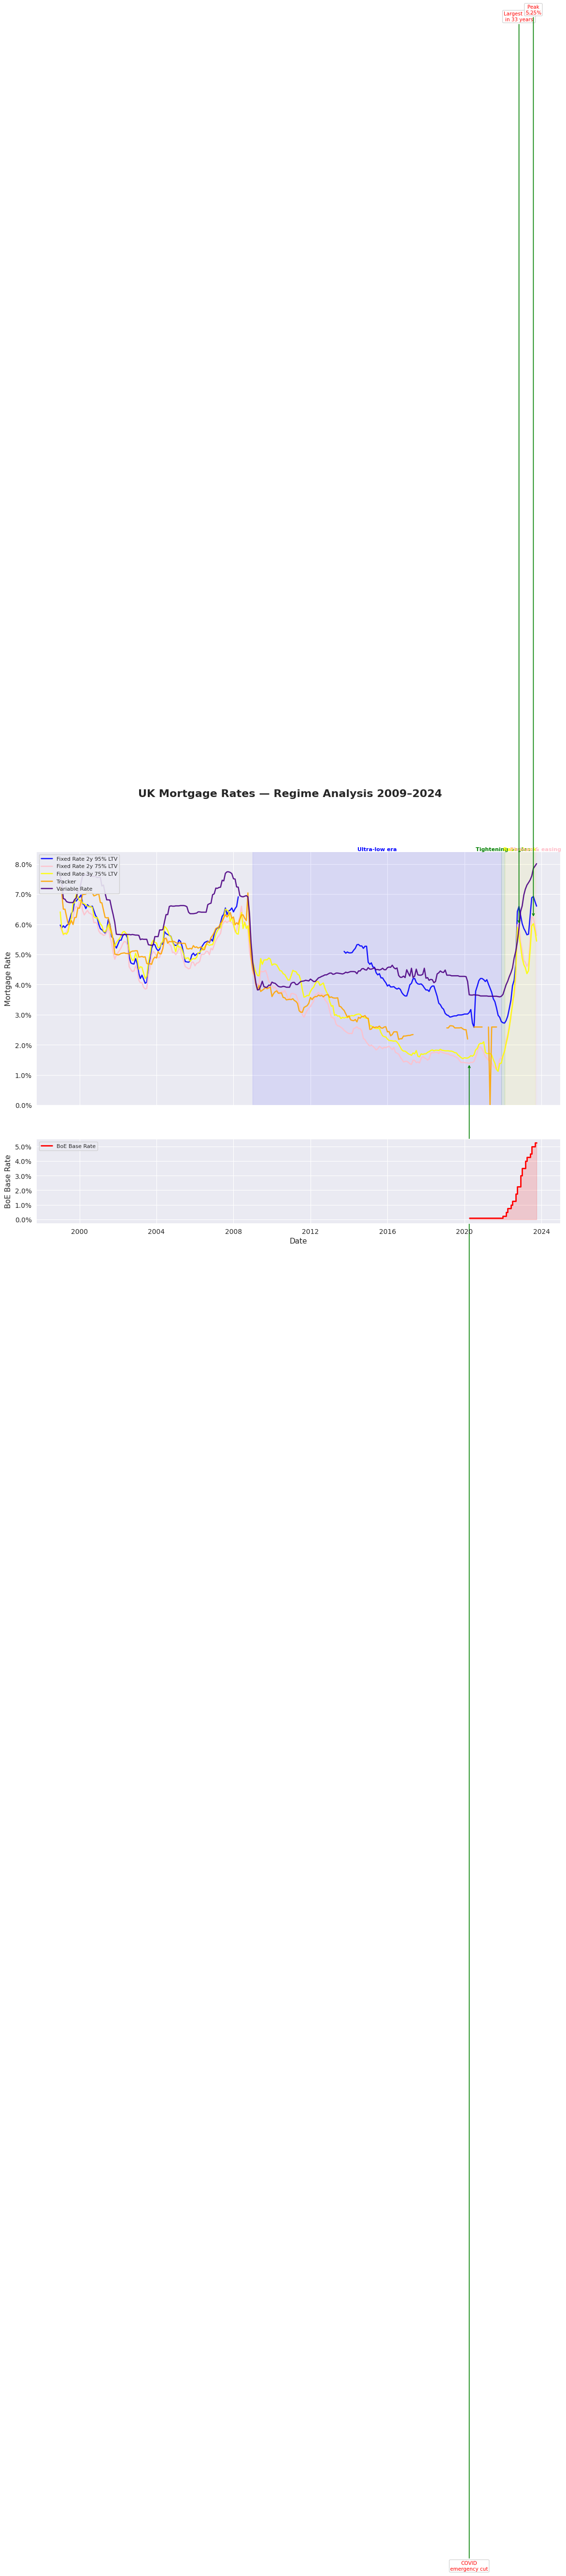

Chart saved: regime_analysis.png ✅


In [8]:
fig,(ax1,ax2) = plt.subplots(2,1,figsize=(14,10),sharex=True,gridspec_kw={'height_ratios':[3,1]})
fig.suptitle('UK Mortgage Rates — Regime Analysis 2009–2024',
             fontsize=16, fontweight='bold', y=1.01)

# --- Top panel: mortgage rates ---
colors = ['Blue','Pink','Yellow','Orange','Indigo']
for col, color in zip(RATE_COLS, colors):
    ax1.plot(df.index, df[col], label=col.replace('_', ' '), 
             linewidth=1.8, color=color, alpha=0.9)

# Shade regimes
for start, end, color, label, _ in regimes:
    s = max(pd.Timestamp(start), df.index.min())
    e = min(pd.Timestamp(end), df.index.max())
    ax1.axvspan(s, e, alpha=0.08, color=color, label=f'_{label}')
    mid = s + (e - s) / 2
    ax1.text(mid, ax1.get_ylim()[1] if ax1.get_ylim()[1] > 0 else 0.12,
             label, ha='center', fontsize=8, color=color,
             fontweight='bold', va='bottom')

# Annotate key events
key_annotations = [
    ('2020-03-19', 'COVID\nemergency cut', -0.5),
    ('2022-11-03', 'Largest hike\nin 33 years', 0.3),
    ('2023-08-03', 'Peak\n5.25%', 0.3),
    ('2024-08-01', 'First cut\nsince 2020', -0.5),
]
for date, text, yoffset in key_annotations:
    ts = pd.Timestamp(date)
    if ts in df.index or (ts > df.index.min() and ts < df.index.max()):
        nearest = df.index[df.index.get_indexer([ts], method='nearest')[0]]
        y_val = df[RATE_COLS[1]].loc[nearest]
        ax1.annotate(text,
                     xy=(nearest, y_val),
                     xytext=(nearest, y_val + yoffset),
                     fontsize=7.5, ha='center', color='Red',
                     arrowprops=dict(arrowstyle='->', color='Green', lw=1.2),
                     bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8, ec='#cccccc'))

ax1.yaxis.set_major_formatter(pct_fmt)
ax1.set_ylabel('Mortgage Rate', fontsize=11)
ax1.legend(loc='upper left', fontsize=8, framealpha=0.9)
ax1.set_ylim(bottom=0)

# --- Bottom panel: BoE base rate ---
boe_full = boe_df['rate'].resample('MS').ffill()
boe_full = boe_full.reindex(df.index, method='ffill')
ax2.step(boe_full.index, boe_full.values, where='post',
         color='Red', linewidth=2, label='BoE Base Rate')
ax2.fill_between(boe_full.index, boe_full.values, step='post',
                 alpha=0.15, color='Red')
ax2.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.1f}%'))
ax2.set_ylabel('BoE Base Rate', fontsize=11)
ax2.set_xlabel('Date', fontsize=11)
ax2.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('regime_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: regime_analysis.png ✅")

Lag Analysis

In [9]:
# How many days did mortgage rates LAG behind BoE moves?

lag_results = []

major_hikes = boe_df[boe_df['rate'].diff() > 0].copy()

for hike_date, row in major_hikes.iterrows():
    # Find when each mortgage rate crossed the new BoE level
    window = df[df.index >= hike_date][RATE_COLS].head(12)  # 12 months post hike
    for col in RATE_COLS:
        # Find first month where rate exceeded BoE rate
        above = window[col][window[col] > row['rate']]
        if len(above) > 0:
            lag_days = (above.index[0] - hike_date).days
            lag_results.append({
                'hike_date': hike_date,
                'boe_rate': row['rate'],
                'mortgage_type': col,
                'lag_days': lag_days
            })

lag_df = pd.DataFrame(lag_results)

if len(lag_df) > 0:
    avg_lag = lag_df.groupby('mortgage_type')['lag_days'].mean().sort_values()
    print("=== AVERAGE LAG: BoE hike → mortgage rate response ===\n")
    for mtype, days in avg_lag.items():
        print(f"  {mtype:<35} {days:.0f} days avg lag")
    
    print("\n💡 KEY INSIGHT: Fixed rates respond faster than trackers/variable")
    print("   because lenders pre-price expected hikes into fixed deals")

Regime Statistics table

In [10]:
regime_stats = []

for start, end, color, label, _ in regimes:
    s, e = pd.Timestamp(start), pd.Timestamp(end)
    mask = (df.index >= s) & (df.index <= e)
    subset = df.loc[mask, RATE_COLS]
    if len(subset) > 0:
        regime_stats.append({
            'Regime': label,
            'Period': f"{s.strftime('%b %Y')} – {e.strftime('%b %Y')}",
            'Avg 2yr Fixed 75%': f"{subset['Fixed_Rate_2y_75%_LTV'].mean():.2%}",
            'Avg Tracker': f"{subset['Tracker'].mean():.2%}",
            'Peak 2yr Fixed': f"{subset['Fixed_Rate_2y_75%_LTV'].max():.2%}",
            'Months': len(subset)
        })

regime_table = pd.DataFrame(regime_stats)
display(regime_table)

# Save for README
regime_table.to_csv('regime_summary.csv', index=False)
print("\nregime_summary.csv saved")

,Regime,Period,Avg 2yr Fixed 75%,Avg Tracker,Peak 2yr Fixed,Months
0,Ultra-low era,Jan 2009 – Nov 2021,2.42%,3.02%,4.47%,155
1,Tightening begins,Dec 2021 – Jan 2022,1.61%,nan%,1.64%,2
2,Rate shock,Feb 2022 – Aug 2023,4.33%,nan%,6.25%,19
3,Plateau & easing,Sep 2023 – Dec 2024,5.79%,nan%,5.94%,2



regime_summary.csv saved
